In [5]:
%pip install qiskit-aer-gpu cuquantum

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 7.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 8.6 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 9.4 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 MB 7.6 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 9.0 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 8.4 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.6/306.6 MB 8.1 MB/s  0:00:38m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 61.3 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 80.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Jedna, początkowa iteracja

>>> Przygotowano dane klasyczne i zważone dane kwantowe. Skonfigurowano HUB na Kubicie 1.
>>> ZNALEZIONO PLIK WYNIKOWY: phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.csv. Wczytywanie macierzy bez obciążania QPU...

>>> Start ewaluacji Walk-Forward: Zoptymalizowany Quantum SVM (HUB 1) vs Classical SVM...

--- OSTATECZNE WYNIKI DLA PUBLIKACJI (WALK-FORWARD) ---


,Accuracy,AUC ROC,MCC,Opt Threshold
Zoptymalizowany Kwantowy SVM (HUB Q1),0.5597,0.5437,0.0834,0.4600
Klasyczny SVM (Raw Data),0.5479,0.5125,0.0563,0.4700


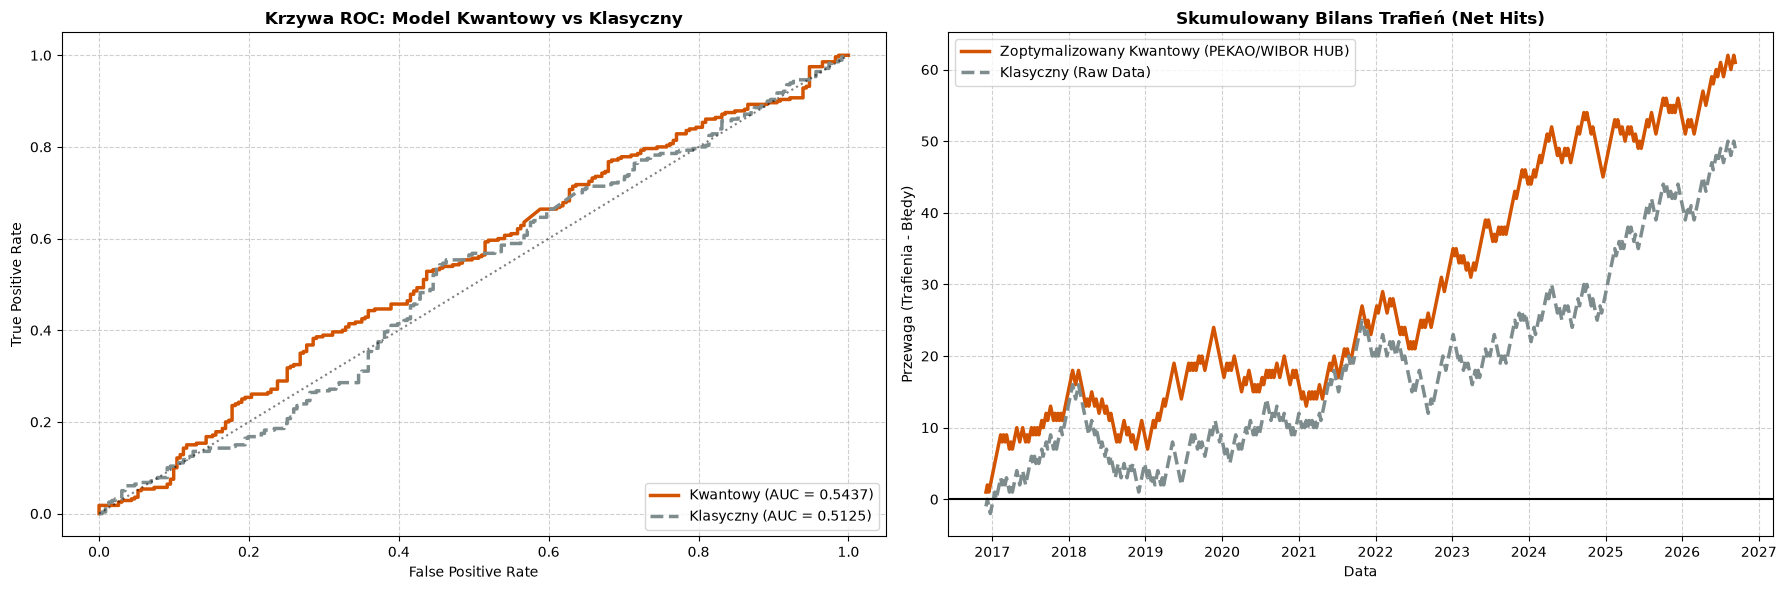

In [2]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, matthews_corrcoef

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. ZWYCIĘSKA KONFIGURACJA (RANK 1)
# ==========================================
# Topologia gwiazdy wokół Q1 (PEKAO + WIBOR)
HUB_QUBIT = 1

# Optymalne wagi wyznaczone przez algorytm ewolucyjny
OPTIMAL_WEIGHTS = [0.86, 1.00, 0.80, 0.27, 0.95]

FEATURES_MAP = [
    'pbv_pko', 'zmiennosc',        # Kubit 0 (Sat: Waga 0.86)
    'pbv_peo', 'wibor_3m',         # Kubit 1 (HUB: Waga 1.00)
    'pbv_san', 'wig20',            # Kubit 2 (Sat: Waga 0.80)
    'pbv_ing', 'eurpln',           # Kubit 3 (Sat: Waga 0.27)
    'pbv_mbk', 'rentownosc_10y'    # Kubit 4 (Sat: Waga 0.95)
]

PROJECTIONS_FILE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.csv"

# ==========================================
# 2. PRZYGOTOWANIE BAZY DANYCH (CAUSAL SCALING)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"
df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    X_norm_list.append(np.clip(current_scaled, 0.0, 2 * np.pi))
    valid_indices.append(t)

X_quantum_base = np.array(X_norm_list)
X_classical_valid = X_raw[valid_indices]
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]

# Aplikacja zoptymalizowanych wag do cech kwantowych
multipliers = np.zeros(10)
for q in range(5):
    multipliers[2*q] = OPTIMAL_WEIGHTS[q]
    multipliers[2*q + 1] = OPTIMAL_WEIGHTS[q]
X_quantum_opt = X_quantum_base * multipliers

print(f">>> Przygotowano dane klasyczne i zważone dane kwantowe. Skonfigurowano HUB na Kubicie {HUB_QUBIT}.")

# ==========================================
# 3. POZYSKIWANIE RZUTÓW KWANTOWYCH (PQK)
# ==========================================
def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

# Jeśli plik CSV z rzutami istnieje, po prostu go wczytaj
if os.path.exists(PROJECTIONS_FILE):
    print(f">>> ZNALEZIONO PLIK WYNIKOWY: {PROJECTIONS_FILE}. Wczytywanie macierzy bez obciążania QPU...")
    # Zakładamy, że pierwsza kolumna to indeks czasowy, a reszta to 15 rzutów
    df_phi = pd.read_csv(PROJECTIONS_FILE, index_col=0)
    Phi_real = df_phi.values
else:
    print(f">>> BRAK PLIKU {PROJECTIONS_FILE}. Kod gotowy do podłączenia pod QPU / Symulator.")
    # Tutaj wywołalibyśmy standardową funkcję get_secure_qpu_projections()
    # Dla uproszczenia (aby kod nie wywalił się u Ciebie bez tokenu) podstawiamy losowy szum:
    raise FileNotFoundError(f"Upewnij się, że plik {PROJECTIONS_FILE} znajduje się w folderze ze skryptem!")

# ==========================================
# 4. KROCZĄCA WALIDACJA (WALK-FORWARD)
# ==========================================
print("\n>>> Start ewaluacji Walk-Forward: Zoptymalizowany Quantum SVM (HUB 1) vs Classical SVM...")

TRAIN_WINDOW = 52
inner_cv = TimeSeriesSplit(n_splits=3)
param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}

pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

results = {"y_true": [], "dates": [], "prob_qpu": [], "prob_cls": []}

for t in range(TRAIN_WINDOW, len(y)):
    # Wycinamy okno treningowe (52 tygodnie wstecz) i 1 tydzień do przodu (test)
    Phi_tr, Phi_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    X_cls_tr, X_cls_te = X_classical_valid[t - TRAIN_WINDOW : t], X_classical_valid[t : t + 1]
    
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Model Kwantowy
    search_qpu = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(Phi_tr, y_tr)
    results["prob_qpu"].append(search_qpu.predict_proba(Phi_te)[0, 1])
    
    # Model Klasyczny
    search_cls = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(X_cls_tr, y_tr)
    results["prob_cls"].append(search_cls.predict_proba(X_cls_te)[0, 1])

y_true = np.array(results["y_true"])
prob_qpu = np.array(results["prob_qpu"])
prob_cls = np.array(results["prob_cls"])

# Znajdowanie optymalnego progu cięcia
def get_best_preds(probs, y_true):
    best_thresh, best_acc = 0.50, 0
    for thresh in np.arange(0.40, 0.60, 0.01):
        acc = accuracy_score(y_true, (probs > thresh).astype(int))
        if acc > best_acc: best_acc, best_thresh = acc, thresh
    return (probs > best_thresh).astype(int), best_thresh

pred_qpu, thresh_qpu = get_best_preds(prob_qpu, y_true)
pred_cls, thresh_cls = get_best_preds(prob_cls, y_true)

# ==========================================
# 5. METRYKI PUBLIKACYJNE I WIZUALIZACJA
# ==========================================
def compute_metrics(y_t, pred, probs, thresh):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "AUC ROC": roc_auc_score(y_t, probs),
        "MCC": matthews_corrcoef(y_t, pred),
        "Opt Threshold": thresh
    }

df_metrics = pd.DataFrame({
    "Zoptymalizowany Kwantowy SVM (HUB Q1)": compute_metrics(y_true, pred_qpu, prob_qpu, thresh_qpu),
    "Klasyczny SVM (Raw Data)": compute_metrics(y_true, pred_cls, prob_cls, thresh_cls)
}).T

print("\n--- OSTATECZNE WYNIKI DLA PUBLIKACJI (WALK-FORWARD) ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fpr_qpu, tpr_qpu, _ = roc_curve(y_true, prob_qpu)
fpr_cls, tpr_cls, _ = roc_curve(y_true, prob_cls)

# Złota krzywa ROC dla rozwiązania kwantowego
ax[0].plot(fpr_qpu, tpr_qpu, color="#d35400", lw=2.5, label=f'Kwantowy (AUC = {df_metrics.loc["Zoptymalizowany Kwantowy SVM (HUB Q1)", "AUC ROC"]:.4f})')
ax[0].plot(fpr_cls, tpr_cls, color="#7f8c8d", lw=2.5, ls="--", label=f'Klasyczny (AUC = {df_metrics.loc["Klasyczny SVM (Raw Data)", "AUC ROC"]:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC: Model Kwantowy vs Klasyczny', fontweight='bold', fontsize=12)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Krzywa kapitału (Net Hits)
net_hits_qpu = np.cumsum(np.where(pred_qpu == y_true, 1, -1))
net_hits_cls = np.cumsum(np.where(pred_cls == y_true, 1, -1))

ax[1].plot(results["dates"], net_hits_qpu, color="#d35400", lw=2.5, label="Zoptymalizowany Kwantowy (PEKAO/WIBOR HUB)")
ax[1].plot(results["dates"], net_hits_cls, color="#7f8c8d", lw=2.5, ls="--", label="Klasyczny (Raw Data)")
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Net Hits)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Przewaga (Trafienia - Błędy)')
ax[1].legend(loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Test stabilności modelu - 7 iteracji (CPU + QPU)

In [ ]:
import os
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# IMPORTY 
# ==========================================
from qiskit import QuantumCircuit, transpile
from iqm.qiskit_iqm import IQMProvider
from dotenv import load_dotenv

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, matthews_corrcoef

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA TESTU (FIZYCZNA ODRA)
# ==========================================
NUM_RUNS = 10
TRAIN_WINDOW = 52
HUB_QUBIT = 1
OPTIMAL_WEIGHTS = [0.86, 1.00, 0.80, 0.27, 0.95]
BATCH_SIZE = 50 
SHOTS = 4000

FEATURES_MAP = [
    'pbv_pko', 'zmiennosc',        
    'pbv_peo', 'wibor_3m',         
    'pbv_san', 'wig20',            
    'pbv_ing', 'eurpln',           
    'pbv_mbk', 'rentownosc_10y'    
]

RESULTS_CSV = "stability_qpu_odra_results.csv"
SUMMARY_CSV = "stability_qpu_odra_summary.csv"

# ==========================================
# 2. PODŁĄCZENIE DO ODRY
# ==========================================
print(">>> Inicjalizacja połączenia z IQM Odra...")
load_dotenv("/home/gciapa/Projekt_QML_WIG/Projekt/big-bank_9)Finalny kod i testy stat/token.env")
server_url = os.getenv("SERVER")
token_val = os.getenv("TOKEN")

if not server_url:
    raise ValueError("Brak adresu SERVER w pliku token.env!")

provider = IQMProvider(server_url, token=token_val)
backend = provider.get_backend("Odra")
print(f">>> Sukces: Podłączono do backendu {backend.name}")

# ==========================================
# 3. PRZYGOTOWANIE BAZY DANYCH
# ==========================================
csv_path = "/home/gciapa/Projekt_QML_WIG/Projekt/big-bank_9)Finalny kod i testy stat/dataset_final.csv" 

# WCZYTANIE PLIKU CSV NA SAMYM POCZĄTKU SEKCJI
df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

X_norm_list, valid_indices = [], []
for t in range(TRAIN_WINDOW, len(X_raw)):
    past_window = X_raw[t - TRAIN_WINDOW : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    X_norm_list.append(np.clip(current_scaled, 0.0, 2 * np.pi))
    valid_indices.append(t)

X_quantum_base = np.array(X_norm_list)
X_classical_valid = X_raw[valid_indices]
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]

multipliers = np.zeros(10)
for q in range(5):
    multipliers[2*q] = OPTIMAL_WEIGHTS[q]
    multipliers[2*q + 1] = OPTIMAL_WEIGHTS[q]
X_quantum_opt = X_quantum_base * multipliers

# ==========================================
# 4. FIZYCZNE WYKONANIE NA QPU
# ==========================================
def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def get_phi_physical_qpu(run_idx, X_q, physical_backend):
    filename = f"qpu_phi_run_{run_idx}.csv"
    
    if os.path.exists(filename):
        print(f"\n[CACHE] Znaleziono plik {filename}. Pomijam kolejkę, wczytuję dane fizyczne z dysku.")
        return pd.read_csv(filename, index_col=0).values

    print(f"\n[HARDWARE] Generowanie obwodów dla Iteracji {run_idx}...")
    all_circuits = []
    for x in X_q:
        qc_base = build_base_ansatz(x, 5, HUB_QUBIT)
        for p in ['X', 'Y', 'Z']:
            for q in range(5):
                qc_measure = qc_base.copy()
                if p == 'X': qc_measure.h(q)
                elif p == 'Y': qc_measure.sdg(q); qc_measure.h(q)
                qc_measure.measure_all()
                all_circuits.append(qc_measure)
                
    print(f"[HARDWARE] Transpilacja pod układ fizyczny Odra (może zająć chwilę)...")
    transpiled = transpile(all_circuits, backend=physical_backend, optimization_level=3)
    
    all_counts = []
    total_batches = (len(transpiled) - 1) // BATCH_SIZE + 1
    
    print(f"[HARDWARE] Podzielono na {total_batches} paczek. Rozpoczynam wysyłanie do API IQM.")
    
    for i in range(0, len(transpiled), BATCH_SIZE):
        batch = transpiled[i : i + BATCH_SIZE]
        current_batch = i // BATCH_SIZE + 1
        print(f"   -> [W KOLEJCE] Wysyłanie paczki {current_batch}/{total_batches} (Czekam na sprzęt...)")
        
        job = physical_backend.run(batch, shots=SHOTS)
        
        for j in range(len(batch)):
            all_counts.append(job.result().get_counts(j))
            
    print(f"[HARDWARE] Zakończono zrzuty kwantowe iteracji {run_idx}. Przeliczam prawdopodobieństwa...")
    
    Phi_qpu = np.zeros((len(X_q), 15))
    idx = 0
    for i in range(len(X_q)):
        for j in range(15):
            counts = all_counts[idx]
            total_shots = sum(counts.values())
            expval = 0
            for bitstring, count in counts.items():
                bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
                q_target = j % 5 
                expval += bits[q_target] * count
            Phi_qpu[i, j] = expval / total_shots
            idx += 1
            
    pd.DataFrame(Phi_qpu).to_csv(filename)
    print(f"[HARDWARE] Zapisano stan macierzy do {filename}. Sukces.")
    return Phi_qpu

# ==========================================
# 5. FUNKCJE POMOCNICZE
# ==========================================
def get_best_preds(probs, y_true):
    best_thresh, best_acc = 0.50, 0
    for thresh in np.arange(0.40, 0.60, 0.01):
        acc = accuracy_score(y_true, (probs > thresh).astype(int))
        if acc > best_acc: best_acc, best_thresh = acc, thresh
    return (probs > best_thresh).astype(int), best_thresh

def format_time(seconds):
    return str(datetime.timedelta(seconds=int(seconds)))

# ==========================================
# 6. GŁÓWNA PĘTLA TESTU STABILNOŚCI QPU
# ==========================================
print(f">>> Rozpoczynam Test Stabilności Hardware: {NUM_RUNS} iteracji Walk-Forward")
start_time_global = time.time()

pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True))])
inner_cv = TimeSeriesSplit(n_splits=3)
param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}

all_results = []
net_hits_history = {"Quantum": [], "Classical": []}

for run in range(1, NUM_RUNS + 1):
    
    Phi_real = get_phi_physical_qpu(run, X_quantum_opt, backend)
    
    results = {"y_true": [], "prob_qpu": [], "prob_cls": []}
    total_steps = len(y) - TRAIN_WINDOW
    
    print(f"\n[ML] Trening maszyn SVM dla iteracji {run} na pobranych pomiarach...")
    for step, t in enumerate(range(TRAIN_WINDOW, len(y))):
        Phi_tr, Phi_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
        X_cls_tr, X_cls_te = X_classical_valid[t - TRAIN_WINDOW : t], X_classical_valid[t : t + 1]
        y_tr = y[t - TRAIN_WINDOW : t]
        
        results["y_true"].append(y[t])
        pipeline.set_params(svm__random_state=(42 * run + t))
        
        search_qpu = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(Phi_tr, y_tr)
        results["prob_qpu"].append(search_qpu.predict_proba(Phi_te)[0, 1])
        
        search_cls = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(X_cls_tr, y_tr)
        results["prob_cls"].append(search_cls.predict_proba(X_cls_te)[0, 1])
        
        if step % 10 == 0 or step == total_steps - 1:
            percent_done = int((step + 1) / total_steps * 100)
            bar = "=" * (percent_done // 5) + "-" * (20 - percent_done // 5)
            print(f"\r[{bar}] ML Step {step+1}/{total_steps}", end="", flush=True)

    y_true_arr = np.array(results["y_true"])
    prob_qpu = np.array(results["prob_qpu"])
    prob_cls = np.array(results["prob_cls"])
    
    pred_qpu, th_qpu = get_best_preds(prob_qpu, y_true_arr)
    pred_cls, th_cls = get_best_preds(prob_cls, y_true_arr)
    
    net_hits_history["Quantum"].append(np.cumsum(np.where(pred_qpu == y_true_arr, 1, -1)))
    net_hits_history["Classical"].append(np.cumsum(np.where(pred_cls == y_true_arr, 1, -1)))

    for model_name, p, pred, th in [("Quantum SVM (Odra HW)", prob_qpu, pred_qpu, th_qpu), 
                                    ("Classical SVM (Raw)", prob_cls, pred_cls, th_cls)]:
        all_results.append({
            "Run": run,
            "Model": model_name,
            "Accuracy": accuracy_score(y_true_arr, pred),
            "AUC ROC": roc_auc_score(y_true_arr, p),
            "F1 Score": f1_score(y_true_arr, pred),
            "MCC": matthews_corrcoef(y_true_arr, pred),
            "Opt Threshold": th
        })
        
    pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)
    print(f"\n[INFO] Zakończono analizę iteracji {run}. Zapisano wyniki do {RESULTS_CSV}")

total_exec_time = time.time() - start_time_global
print(f"\n>>> Zakończono cały test statystyczny! Całkowity czas: {format_time(total_exec_time)}")

# ==========================================
# 7. GENEROWANIE WIZUALIZACJI I WYNIKÓW
# ==========================================
df_res = pd.DataFrame(all_results)
summary_stats = df_res.groupby("Model").agg({
    "Accuracy": ['mean', 'std'],
    "AUC ROC": ['mean', 'std'],
    "F1 Score": ['mean', 'std'],
    "MCC": ['mean', 'std'],
    "Opt Threshold": ['mean']
})
summary_stats.columns = [f"{col[0]}_{col[1]}" for col in summary_stats.columns]
summary_stats.to_csv(SUMMARY_CSV)

print("\n--- PODSUMOWANIE HARDWARE STABILITY ---")
print(summary_stats)

metrics_to_plot = ["Accuracy", "AUC ROC", "F1 Score", "MCC"]
colors = {"Quantum SVM (Odra HW)": "#8e44ad", "Classical SVM (Raw)": "#27ae60"}

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    for model in colors.keys():
        model_data = df_res[df_res["Model"] == model]
        plt.plot(model_data["Run"], model_data[metric], marker='o', lw=2.5, 
                 color=colors[model], label=f'{model} (Mean: {model_data[metric].mean():.3f} ± {model_data[metric].std():.3f})')
        
    plt.title(f'{metric} Stability on Physical QPU ({NUM_RUNS} Iterations)', fontweight='bold', fontsize=14)
    plt.xlabel('Run Number', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(range(1, NUM_RUNS + 1))
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f"Hardware_Stability_{metric.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.close()

plt.figure(figsize=(12, 7))
plot_dates = dates[TRAIN_WINDOW:]
for i in range(NUM_RUNS):
    plt.plot(plot_dates, net_hits_history["Quantum"][i], color="#8e44ad", alpha=0.3, lw=1.5)
    plt.plot(plot_dates, net_hits_history["Classical"][i], color="#27ae60", alpha=0.3, lw=1.5)

plt.plot(plot_dates, np.mean(net_hits_history["Quantum"], axis=0), color="#8e44ad", lw=3, label="Quantum SVM (Avg on QPU)")
plt.plot(plot_dates, np.mean(net_hits_history["Classical"], axis=0), color="#27ae60", lw=3, ls="--", label="Classical SVM (Avg)")
plt.axhline(0, color='black', lw=1.5)
plt.title('Cumulative Net Hits Stability (QPU Odra)', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Net Advantage', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("Hardware_Stability_Cumulative_Net_Hits.png", dpi=300, bbox_inches='tight')
plt.close()